# 03 — Ecommify: Benchmarks y Evidencias de Rendimiento

**Prerrequisito**: Notebooks 01 y 02 ejecutados (datos cargados).

Este notebook captura evidencias cuantitativas **ANTES** y **DESPUÉS** de optimizaciones:
- PostgreSQL: EXPLAIN ANALYZE para 5 queries críticas
- MongoDB: .explain() para 4 queries con y sin índice
- Gráficas comparativas de rendimiento

## 1. Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!pip install --quiet psycopg2-binary 'pymongo[srv]' matplotlib pandas
import psycopg2, getpass, json, os, time
from psycopg2.extras import RealDictCursor
from pymongo import MongoClient
import matplotlib.pyplot as plt
import pandas as pd
from datetime import datetime
from google.colab import userdata


SUPABASE_URI = userdata.get('SUPABASE_URI')
ATLAS_URI    = userdata.get('ATLAS_URI')
DATA_DIR     = '/content/drive/MyDrive/Colab Notebooks/MaestriaArch-OBD-U5/evidencias'

pg = psycopg2.connect(SUPABASE_URI, options='-c statement_timeout=120000')
mc = MongoClient(ATLAS_URI)
db = mc['ecommify']

os.makedirs(DATA_DIR, exist_ok=True)
TIMESTAMP = datetime.now().strftime('%Y%m%d_%H%M%S')
results, explain_plans = [], {}
print('Setup OK. Timestamp:', TIMESTAMP)

Setup OK. Timestamp: 20260616_000208


## 2. Helper functions

In [3]:
def pg_explain(label, sql, params=None):
    """Ejecuta EXPLAIN ANALYZE y retorna dict con métricas."""
    with pg.cursor() as cur:
        explain_sql = f'EXPLAIN (ANALYZE, BUFFERS, FORMAT JSON) {sql}'
        try:
            cur.execute(explain_sql, params)
            plan = cur.fetchone()[0]
            ms   = plan[0]['Execution Time']
            rows = plan[0]['Plan'].get('Actual Rows', 0)
            node = plan[0]['Plan']['Node Type']
            explain_plans[label] = plan[0]
            print(f'  [{label}] {ms:8.2f} ms  rows={rows}  plan={node}')
            return {'label': label, 'ms': ms, 'rows': rows, 'plan_type': node}
        except Exception as e:
            print(f'  [{label}] ERROR: {e}')
            pg.rollback()
            return {'label': label, 'ms': -1, 'rows': 0, 'plan_type': 'ERROR'}

def mdb_explain(label, collection, filter_or_pipeline, is_agg=False, drop_index=None):
    """Ejecuta explain() y retorna dict con métricas."""
    try:
        if is_agg:
            result = db.command('aggregate', collection.name,
                                pipeline=filter_or_pipeline,
                                explain=True, cursor={})
            ms = 0  # pipeline explain no siempre tiene executionTimeMillis en M0
            de = 0; dr = 0
        else:
            result = collection.find(filter_or_pipeline).explain()
            stats = result.get('executionStats', {})
            ms = stats.get('executionTimeMillis', 0)
            de = stats.get('totalDocsExamined', 0)
            dr = stats.get('nReturned', 0)
        ratio = de / max(dr, 1)
        explain_plans[label] = result
        print(f'  [{label}] {ms:6.0f} ms  examined={de}  returned={dr}  ratio={ratio:.1f}')
        return {'label': label, 'ms': ms, 'docs_examined': de,
                'docs_returned': dr, 'efficiency_ratio': ratio}
    except Exception as e:
        print(f'  [{label}] ERROR: {e}')
        return {'label': label, 'ms': -1, 'docs_examined': 0, 'docs_returned': 0, 'efficiency_ratio': 999}

print('Helpers listos')

Helpers listos


# Eliminar indices PG

In [5]:
print("=== Eliminando índices adicionales para simular escenario ANTES ===")

DROP_EXTRA_INDEXES_SQL = """

set statement_timeout = '10min';

DROP INDEX IF EXISTS public.idx_geo_location_gist;

DROP INDEX IF EXISTS public.idx_customers_state;
DROP INDEX IF EXISTS public.idx_customers_unique;

DROP INDEX IF EXISTS public.idx_sellers_state;

DROP INDEX IF EXISTS public.idx_products_specs_gin;
DROP INDEX IF EXISTS public.idx_products_tags_gin;
DROP INDEX IF EXISTS public.idx_products_cat_trgm;
DROP INDEX IF EXISTS public.idx_products_updated;

DROP INDEX IF EXISTS public.idx_orders_customer;
DROP INDEX IF EXISTS public.idx_orders_updated;
DROP INDEX IF EXISTS public.idx_orders_purchase_brin;

DROP INDEX IF EXISTS public.idx_items_product;
DROP INDEX IF EXISTS public.idx_items_seller;

DROP INDEX IF EXISTS public.idx_payments_type;

DROP INDEX IF EXISTS public.uidx_mv_sales_cat_month;

DROP INDEX IF EXISTS idx_mv_sales_month_category_revenue;

DROP INDEX IF EXISTS idx_customers_zip_code_prefix;

DROP INDEX IF EXISTS idx_warehouses_name;

DROP INDEX IF EXISTS idx_warehouses_location_gist;

"""

try:
    with pg.cursor() as cur:
        cur.execute(DROP_EXTRA_INDEXES_SQL)

        # Refrescar estadísticas para que el planner no use estimaciones viejas
        cur.execute("ANALYZE geolocation;")
        cur.execute("ANALYZE customers;")
        cur.execute("ANALYZE sellers;")
        cur.execute("ANALYZE products;")
        cur.execute("ANALYZE orders;")
        cur.execute("ANALYZE order_items;")
        cur.execute("ANALYZE order_payments;")

        # La MV puede no tener datos aún, por eso va protegida
        cur.execute("""
            DO $$
            BEGIN
                IF EXISTS (
                    SELECT 1
                    FROM pg_matviews
                    WHERE schemaname = 'public'
                      AND matviewname = 'mv_sales_by_category_monthly'
                ) THEN
                    ANALYZE mv_sales_by_category_monthly;
                END IF;
            END $$;
        """)

    pg.commit()

except Exception as e:
    pg.rollback()
    print("Error eliminando índices adicionales:", e)
    raise

print("Índices adicionales eliminados.")
print("Se conservan PRIMARY KEY, UNIQUE, FOREIGN KEY y CHECK.")

=== Eliminando índices adicionales para simular escenario ANTES ===
Índices adicionales eliminados.
Se conservan PRIMARY KEY, UNIQUE, FOREIGN KEY y CHECK.


# Verificar Indices

In [6]:
print("=== Índices actuales en PostgreSQL ===")

with pg.cursor() as cur:
    cur.execute("""
        SELECT
            schemaname,
            tablename,
            indexname,
            indexdef
        FROM pg_indexes
        WHERE schemaname = 'public'
        ORDER BY tablename, indexname;
    """)

    rows = cur.fetchall()

for r in rows:
    print(f"\nTabla:  {r[1]}")
    print(f"Índice: {r[2]}")
    print(f"DDL:    {r[3]}")

=== Índices actuales en PostgreSQL ===

Tabla:  customers
Índice: customers_customer_unique_id_key
DDL:    CREATE UNIQUE INDEX customers_customer_unique_id_key ON public.customers USING btree (customer_unique_id)

Tabla:  customers
Índice: customers_pkey
DDL:    CREATE UNIQUE INDEX customers_pkey ON public.customers USING btree (customer_id)

Tabla:  geolocation
Índice: geolocation_pkey
DDL:    CREATE UNIQUE INDEX geolocation_pkey ON public.geolocation USING btree (zip_code_prefix)

Tabla:  order_items
Índice: order_items_pkey
DDL:    CREATE UNIQUE INDEX order_items_pkey ON public.order_items USING btree (order_id, order_purchase_timestamp, order_item_id)

Tabla:  order_payments
Índice: order_payments_pkey
DDL:    CREATE UNIQUE INDEX order_payments_pkey ON public.order_payments USING btree (order_id, order_purchase_timestamp, payment_sequential)

Tabla:  orders
Índice: orders_pkey
DDL:    CREATE UNIQUE INDEX orders_pkey ON ONLY public.orders USING btree (order_id, order_purchase_timest

## 3. PostgreSQL — Benchmarks ANTES de optimizaciones adicionales

In [7]:
print('=== PostgreSQL ANTES ===')

# Q1: Rango de fecha sobre tabla particionada (verifica partition pruning)
results.append(pg_explain('PG_Q1_rango_fecha_ANTES',
    """SELECT o.order_id, o.order_status, o.order_purchase_timestamp
       FROM orders o
       WHERE o.order_purchase_timestamp BETWEEN '2018-01-01' AND '2018-12-31'
       LIMIT 500"""))

# Q2: JOIN customers + orders + payments (query OLTP típica)
results.append(pg_explain('PG_Q2_join_oltp_ANTES',
    """SELECT o.order_id, c.customer_state, SUM(op.payment_value) as total
       FROM orders o
       JOIN customers c ON c.customer_id = o.customer_id
       JOIN order_payments op ON op.order_id = o.order_id
                              AND op.order_purchase_timestamp = o.order_purchase_timestamp
       WHERE o.order_status = 'delivered'
         AND o.order_purchase_timestamp >= '2018-06-01'
       GROUP BY o.order_id, c.customer_state
       LIMIT 100"""))

# Q3: PostGIS — clientes más cercanos al depósito SP (verifica índice GIST)
results.append(pg_explain('PG_Q3_postgis_ANTES',
    """SELECT c.customer_id, c.customer_state,
              ST_Distance(g.location, w.location) / 1000.0 AS dist_km
       FROM customers c
       JOIN geolocation g ON g.zip_code_prefix = c.zip_code_prefix
       JOIN warehouses w ON w.name = 'Deposito SP Centro'
       WHERE ST_DWithin(g.location, w.location, 50000)
       LIMIT 100"""))

# Q4: pg_trgm fuzzy search
results.append(pg_explain('PG_Q4_trgm_ANTES',
    """SELECT product_id, product_category_name,
              similarity(product_category_name, 'telefona') AS sim
       FROM products
       WHERE product_category_name % 'telefona'
       ORDER BY sim DESC LIMIT 10"""))

# Q5: MV ventas por categoría (si ya tiene datos)
results.append(pg_explain('PG_Q5_mv_ventas_ANTES',
    """SELECT category, SUM(gross_revenue) as revenue
       FROM mv_sales_by_category_monthly
       WHERE year_month >= '2018-01-01'
       GROUP BY category ORDER BY revenue DESC LIMIT 10"""))

print('\nCapturas ANTES completadas.')

=== PostgreSQL ANTES ===
  [PG_Q1_rango_fecha_ANTES]     0.40 ms  rows=500  plan=Limit
  [PG_Q2_join_oltp_ANTES]   601.67 ms  rows=100  plan=Limit
  [PG_Q3_postgis_ANTES]   134.53 ms  rows=100  plan=Limit
  [PG_Q4_trgm_ANTES]    86.70 ms  rows=10  plan=Limit
  [PG_Q5_mv_ventas_ANTES]     0.81 ms  rows=10  plan=Limit

Capturas ANTES completadas.


# Reconstruir indices PG

In [8]:
print("=== Reconstruyendo índices adicionales para escenario DESPUÉS ===")

RECREATE_EXTRA_INDEXES_SQL = """

set statement_timeout = '10min';

CREATE INDEX IF NOT EXISTS idx_geo_location_gist
    ON geolocation USING GIST (location);

CREATE INDEX IF NOT EXISTS idx_customers_state
    ON customers(customer_state);

CREATE INDEX IF NOT EXISTS idx_customers_unique
    ON customers(customer_unique_id);

CREATE INDEX IF NOT EXISTS idx_sellers_state
    ON sellers(seller_state);

CREATE INDEX IF NOT EXISTS idx_products_specs_gin
    ON products USING GIN(specifications jsonb_path_ops);

CREATE INDEX IF NOT EXISTS idx_products_tags_gin
    ON products USING GIN(tags);

CREATE INDEX IF NOT EXISTS idx_products_cat_trgm
    ON products USING GIN(product_category_name gin_trgm_ops);

CREATE INDEX IF NOT EXISTS idx_products_updated
    ON products(updated_at);

CREATE INDEX IF NOT EXISTS idx_orders_customer
    ON orders(customer_id);

CREATE INDEX IF NOT EXISTS idx_orders_updated
    ON orders(updated_at);

CREATE INDEX IF NOT EXISTS idx_orders_purchase_brin
    ON orders USING BRIN(order_purchase_timestamp);

CREATE INDEX IF NOT EXISTS idx_items_product
    ON order_items(product_id);

CREATE INDEX IF NOT EXISTS idx_items_seller
    ON order_items(seller_id);

CREATE INDEX IF NOT EXISTS idx_payments_type
    ON order_payments(payment_type);

CREATE UNIQUE INDEX IF NOT EXISTS uidx_mv_sales_cat_month
    ON mv_sales_by_category_monthly (year_month, category);

    -- Mejora el JOIN desde geolocation hacia customers
CREATE INDEX IF NOT EXISTS idx_customers_zip_code_prefix
    ON customers(zip_code_prefix);

-- Mejora el filtro del depósito por nombre
CREATE INDEX IF NOT EXISTS idx_warehouses_name
    ON warehouses(name);

-- Opcional: útil si en el futuro haces búsquedas espaciales sobre warehouses
CREATE INDEX IF NOT EXISTS idx_warehouses_location_gist
    ON warehouses USING GIST(location);

    -- Índice adicional para consultas analíticas por rango de fecha y agregación de revenue.
CREATE INDEX IF NOT EXISTS idx_mv_sales_month_category_revenue
    ON mv_sales_by_category_monthly (year_month, category)
    INCLUDE (gross_revenue, gross_sales, orders_count, avg_item_price);

ANALYZE mv_sales_by_category_monthly;
"""

try:
    with pg.cursor() as cur:
        cur.execute(RECREATE_EXTRA_INDEXES_SQL)

        # Refrescar estadísticas después de crear índices
        cur.execute("ANALYZE geolocation;")
        cur.execute("ANALYZE customers;")
        cur.execute("ANALYZE sellers;")
        cur.execute("ANALYZE products;")
        cur.execute("ANALYZE orders;")
        cur.execute("ANALYZE order_items;")
        cur.execute("ANALYZE order_payments;")
        cur.execute("ANALYZE mv_sales_by_category_monthly;")

    pg.commit()

except Exception as e:
    pg.rollback()
    print("Error reconstruyendo índices adicionales:", e)
    raise

print("Índices adicionales reconstruidos.")

=== Reconstruyendo índices adicionales para escenario DESPUÉS ===
Índices adicionales reconstruidos.


# Validar Indices: Tamaño

In [9]:
print("=== Índices reconstruidos ===")

with pg.cursor() as cur:
    cur.execute("""
        SELECT
            tablename,
            indexname,
            pg_size_pretty(pg_relation_size(indexname::regclass)) AS index_size
        FROM pg_indexes
        WHERE schemaname = 'public'
        ORDER BY tablename, indexname;
    """)

    rows = cur.fetchall()

print(f"{'Tabla':30s} {'Índice':45s} {'Tamaño':>12s}")
print("-" * 92)

for table_name, index_name, index_size in rows:
    print(f"{table_name:30s} {index_name:45s} {index_size:>12s}")

=== Índices reconstruidos ===
Tabla                          Índice                                              Tamaño
--------------------------------------------------------------------------------------------
customers                      customers_customer_unique_id_key                   3968 kB
customers                      customers_pkey                                     4088 kB
customers                      idx_customers_state                                 672 kB
customers                      idx_customers_unique                               2976 kB
customers                      idx_customers_zip_code_prefix                       992 kB
geolocation                    geolocation_pkey                                    432 kB
geolocation                    idx_geo_location_gist                              1480 kB
mv_sales_by_category_monthly   idx_mv_sales_month_category_revenue                 128 kB
mv_sales_by_category_monthly   uidx_mv_sales_cat_month             

## 4. Refrescar MV y verificar optimizaciones

In [10]:
# Refrescar la vista materializada (primera vez con datos reales)
print('Refrescando vista materializada mv_sales_by_category_monthly...')
with pg.cursor() as cur:
    cur.execute('REFRESH MATERIALIZED VIEW mv_sales_by_category_monthly')
pg.commit()
print('MV refrescada.')

# Verificar estadísticas de índices
with pg.cursor() as cur:
    cur.execute("""
        SELECT schemaname, tablename, indexname,
               pg_size_pretty(pg_relation_size(indexname::regclass)) as index_size
        FROM pg_indexes
        WHERE schemaname = 'public'
        ORDER BY tablename, indexname;
    """)
    print(f'{'Tabla':25s} {'Índice':40s} {'Tamaño':>10s}')
    print('-' * 78)
    for r in cur.fetchall():
        print(f'  {r[1]:23s} {r[2]:38s} {r[3]:>10s}')

Refrescando vista materializada mv_sales_by_category_monthly...
MV refrescada.
Tabla                     Índice                                       Tamaño
------------------------------------------------------------------------------
  customers               customers_customer_unique_id_key          3968 kB
  customers               customers_pkey                            4088 kB
  customers               idx_customers_state                        672 kB
  customers               idx_customers_unique                      2976 kB
  customers               idx_customers_zip_code_prefix              992 kB
  geolocation             geolocation_pkey                           432 kB
  geolocation             idx_geo_location_gist                     1480 kB
  mv_sales_by_category_monthly idx_mv_sales_month_category_revenue        128 kB
  mv_sales_by_category_monthly uidx_mv_sales_cat_month                     72 kB
  order_items             idx_items_product                         25

## 5. PostgreSQL — Benchmarks DESPUÉS de optimizaciones

In [11]:
print('=== PostgreSQL DESPUÉS ===')

results.append(pg_explain('PG_Q1_rango_fecha_DESPUES',
    """SELECT o.order_id, o.order_status, o.order_purchase_timestamp
       FROM orders o
       WHERE o.order_purchase_timestamp BETWEEN '2018-01-01' AND '2018-12-31'
       LIMIT 500"""))

results.append(pg_explain('PG_Q2_join_oltp_DESPUES',
    """SELECT o.order_id, c.customer_state, SUM(op.payment_value) as total
       FROM orders o
       JOIN customers c ON c.customer_id = o.customer_id
       JOIN order_payments op ON op.order_id = o.order_id
                              AND op.order_purchase_timestamp = o.order_purchase_timestamp
       WHERE o.order_status = 'delivered'
         AND o.order_purchase_timestamp >= '2018-06-01'
       GROUP BY o.order_id, c.customer_state
       LIMIT 100"""))

results.append(pg_explain('PG_Q3_postgis_DESPUES',
    """SELECT c.customer_id, c.customer_state,
              ST_Distance(g.location, w.location) / 1000.0 AS dist_km
       FROM customers c
       JOIN geolocation g ON g.zip_code_prefix = c.zip_code_prefix
       JOIN warehouses w ON w.name = 'Deposito SP Centro'
       WHERE ST_DWithin(g.location, w.location, 50000)
       LIMIT 100"""))

results.append(pg_explain('PG_Q4_trgm_DESPUES',
    """SELECT product_id, product_category_name,
              similarity(product_category_name, 'telefona') AS sim
       FROM products
       WHERE product_category_name % 'telefona'
       ORDER BY sim DESC LIMIT 10"""))

# Q5 DESPUÉS: ahora con MV refrescada
results.append(pg_explain('PG_Q5_mv_ventas_DESPUES',
    """SELECT category, SUM(gross_revenue) as revenue
       FROM mv_sales_by_category_monthly
       WHERE year_month >= '2018-01-01'
       GROUP BY category ORDER BY revenue DESC LIMIT 10"""))

print('Capturas DESPUÉS completadas.')

=== PostgreSQL DESPUÉS ===
  [PG_Q1_rango_fecha_DESPUES]     0.20 ms  rows=500  plan=Limit
  [PG_Q2_join_oltp_DESPUES]   156.86 ms  rows=100  plan=Limit
  [PG_Q3_postgis_DESPUES]     8.21 ms  rows=100  plan=Limit
  [PG_Q4_trgm_DESPUES]     8.96 ms  rows=10  plan=Limit
  [PG_Q5_mv_ventas_DESPUES]     0.52 ms  rows=10  plan=Limit
Capturas DESPUÉS completadas.


## 6. MongoDB — Benchmarks ANTES y DESPUÉS

In [12]:
print('=== MongoDB ANTES (sin índices específicos) ===')

# Eliminar índices para simular estado ANTES
try: db.reviews.drop_index('review_score_1')
except: pass
try: db.geolocation.drop_index('location_2dsphere')
except: pass

# Q1 MDB: reviews por score
results.append(mdb_explain('MDB_Q1_score_ANTES', db.reviews, {'review_score': 5}))

# Q2 MDB: orders_summary por estado
results.append(mdb_explain('MDB_Q2_estado_ANTES', db.orders_summary,
    {'customer.state': 'SP', 'status': 'delivered'}))

# Q3 MDB: Geoespacial sin índice 2dsphere
try:
    results.append(mdb_explain('MDB_Q3_geo_ANTES', db.geolocation, {
        'location': {'$near': {'$geometry': {'type': 'Point',
                    'coordinates': [-46.6333, -23.5505]}, '$maxDistance': 50000}}
    }))
except Exception as e:
    print(f'  MDB_Q3_geo_ANTES: {e} (esperado sin 2dsphere)')
    results.append({'label': 'MDB_Q3_geo_ANTES', 'ms': 9999, 'docs_examined': 999999,
                    'docs_returned': 0, 'efficiency_ratio': 999999})

print('\n=== MongoDB DESPUÉS (con índices) ===')

# Crear índices
db.reviews.create_index([('review_score', 1)])
db.orders_summary.create_index([('customer.state', 1), ('status', 1)])
db.geolocation.create_index([('location', '2dsphere')])

results.append(mdb_explain('MDB_Q1_score_DESPUES', db.reviews, {'review_score': 5}))
results.append(mdb_explain('MDB_Q2_estado_DESPUES', db.orders_summary,
    {'customer.state': 'SP', 'status': 'delivered'}))
results.append(mdb_explain('MDB_Q3_geo_DESPUES', db.geolocation, {
    'location': {'$near': {'$geometry': {'type': 'Point',
                'coordinates': [-46.6333, -23.5505]}, '$maxDistance': 50000}}
}))

print('\nBenchmarks MongoDB completados.')

=== MongoDB ANTES (sin índices específicos) ===
  [MDB_Q1_score_ANTES]     88 ms  examined=98410  returned=56910  ratio=1.7
  [MDB_Q2_estado_ANTES]    199 ms  examined=78178  returned=78178  ratio=1.0
  [MDB_Q3_geo_ANTES] ERROR: error processing query: ns=ecommify.geolocationTree: GEONEAR  field=location maxdist=50000 isNearSphere=0
Sort: {}
Proj: {}
 planner returned error :: caused by :: unable to find index for $geoNear query, full error: {'ok': 0.0, 'errmsg': 'error processing query: ns=ecommify.geolocationTree: GEONEAR  field=location maxdist=50000 isNearSphere=0\nSort: {}\nProj: {}\n planner returned error :: caused by :: unable to find index for $geoNear query', 'code': 291, 'codeName': 'NoQueryExecutionPlans', '$clusterTime': {'clusterTime': Timestamp(1781568751, 2), 'signature': {'hash': b'z\xffq`Jz\xc5\xfb1\x82\xcb\xb8\x01\xd6\xda\x11PXK\xa4', 'keyId': 7610808913255989249}}, 'operationTime': Timestamp(1781568751, 2)}

=== MongoDB DESPUÉS (con índices) ===
  [MDB_Q1_score_DESP

## 7. Generar tabla comparativa y gráficas

In [13]:
df = pd.DataFrame(results)
df_pg  = df[df['label'].str.startswith('PG')].copy()
df_mdb = df[df['label'].str.startswith('MDB')].copy()

# ── Tabla PG antes/después ──
df_pg['query'] = df_pg['label'].str.extract(r'PG_(Q\d+_\w+)_')
df_pg['momento'] = df_pg['label'].str.extract(r'_(ANTES|DESPUES)$')
pivot_pg = df_pg.pivot(index='query', columns='momento', values='ms')
if 'ANTES' in pivot_pg.columns and 'DESPUES' in pivot_pg.columns:
    pivot_pg['mejora_x'] = pivot_pg['ANTES'] / pivot_pg['DESPUES']
    pivot_pg['mejora_pct'] = (1 - pivot_pg['DESPUES'] / pivot_pg['ANTES']) * 100
    print('\n=== PostgreSQL: Tabla comparativa de rendimiento ===')
    print(pivot_pg.round(2).to_string())
    pivot_pg.round(2).to_csv(f'{DATA_DIR}/pg_benchmarks_{TIMESTAMP}.csv')

# ── Tabla MDB antes/después ──
df_mdb['query'] = df_mdb['label'].str.extract(r'MDB_(Q\d+_\w+)_')
df_mdb['momento'] = df_mdb['label'].str.extract(r'_(ANTES|DESPUES)$')
pivot_mdb = df_mdb.pivot(index='query', columns='momento', values='efficiency_ratio')
if 'ANTES' in pivot_mdb.columns and 'DESPUES' in pivot_mdb.columns:
    pivot_mdb['mejora_ratio'] = pivot_mdb['ANTES'] / pivot_mdb['DESPUES']
    print('\n=== MongoDB: Efficiency ratio antes/después (menor = mejor) ===')
    print(pivot_mdb.round(2).to_string())
    pivot_mdb.round(2).to_csv(f'{DATA_DIR}/mdb_benchmarks_{TIMESTAMP}.csv')

print('\nCSVs guardados en {DATA_DIR}')


=== PostgreSQL: Tabla comparativa de rendimiento ===
momento          ANTES  DESPUES  mejora_x  mejora_pct
query                                                
Q1_rango_fecha    0.40     0.20      1.96       48.87
Q2_join_oltp    601.67   156.86      3.84       73.93
Q3_postgis      134.52     8.21     16.38       93.90
Q4_trgm          86.70     8.96      9.68       89.67
Q5_mv_ventas      0.80     0.52      1.54       35.16

=== MongoDB: Efficiency ratio antes/después (menor = mejor) ===
momento     ANTES  DESPUES  mejora_ratio
query                                   
Q1_score     1.73      1.0          1.73
Q2_estado    1.00      1.0          1.00
Q3_geo     999.00      1.0        999.00

CSVs guardados en {DATA_DIR}


## 8. Gráficas comparativas

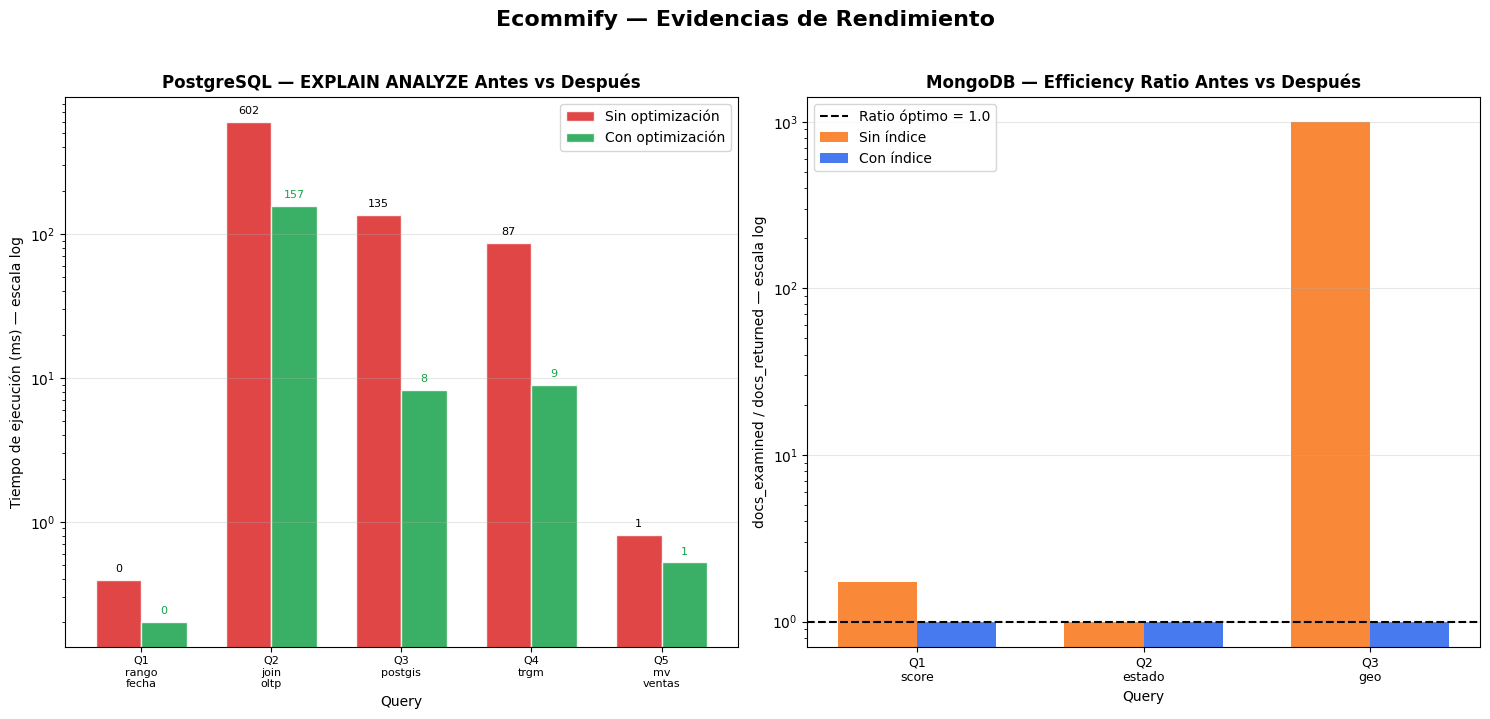

Gráfica guardada: /content/drive/MyDrive/Colab Notebooks/MaestriaArch-OBD-U5/evidencias/benchmark_comparison_20260616_000208.png


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 7))
fig.suptitle('Ecommify — Evidencias de Rendimiento', fontsize=16, fontweight='bold', y=1.02)

# ── PostgreSQL: Tiempo ms ANTES vs DESPUÉS ──
if 'ANTES' in pivot_pg.columns:
    ax = axes[0]
    labels = [l.replace('_', '\n') for l in pivot_pg.index]
    x = range(len(labels))
    w = 0.35
    bars1 = ax.bar([i-w/2 for i in x], pivot_pg.get('ANTES', [0]*len(x)),
                   w, label='Sin optimización', color='#DC2626', alpha=0.85, edgecolor='white')
    bars2 = ax.bar([i+w/2 for i in x], pivot_pg.get('DESPUES', [0]*len(x)),
                   w, label='Con optimización', color='#16A34A', alpha=0.85, edgecolor='white')
    ax.set_yscale('log')
    ax.set_xlabel('Query'); ax.set_ylabel('Tiempo de ejecución (ms) — escala log')
    ax.set_title('PostgreSQL — EXPLAIN ANALYZE Antes vs Después', fontweight='bold')
    ax.set_xticks(list(x)); ax.set_xticklabels(labels, fontsize=8)
    ax.legend(); ax.grid(axis='y', alpha=0.3)
    for bar in bars1: ax.text(bar.get_x()+bar.get_width()/2., bar.get_height()*1.1,
                               f'{bar.get_height():.0f}', ha='center', va='bottom', fontsize=8)
    for bar in bars2: ax.text(bar.get_x()+bar.get_width()/2., bar.get_height()*1.1,
                               f'{bar.get_height():.0f}', ha='center', va='bottom', fontsize=8, color='#16A34A')

# ── MongoDB: Efficiency ratio ANTES vs DESPUÉS ──
if 'ANTES' in pivot_mdb.columns:
    ax2 = axes[1]
    labels_m = [l.replace('_', '\n') for l in pivot_mdb.index]
    xm = range(len(labels_m))
    ax2.bar([i-w/2 for i in xm], pivot_mdb.get('ANTES', [0]*len(xm)),
            w, label='Sin índice', color='#F97316', alpha=0.85)
    ax2.bar([i+w/2 for i in xm], pivot_mdb.get('DESPUES', [0]*len(xm)),
            w, label='Con índice', color='#2563EB', alpha=0.85)
    ax2.axhline(y=1, color='black', linestyle='--', linewidth=1.5, label='Ratio óptimo = 1.0')
    ax2.set_yscale('log')
    ax2.set_xlabel('Query'); ax2.set_ylabel('docs_examined / docs_returned — escala log')
    ax2.set_title('MongoDB — Efficiency Ratio Antes vs Después', fontweight='bold')
    ax2.set_xticks(list(xm)); ax2.set_xticklabels(labels_m, fontsize=9)
    ax2.legend(); ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
output_path = f'{DATA_DIR}/benchmark_comparison_{TIMESTAMP}.png'
plt.savefig(output_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Gráfica guardada: {output_path}')

## 9. Guardar plans EXPLAIN y descargar evidencias

In [ ]:
# Guardar plans EXPLAIN JSON
with open(f'{DATA_DIR}/explain_plans_{TIMESTAMP}.json', 'w') as f:
    json.dump(explain_plans, f, indent=2, default=str)

# Crear README_evidencias.md
readme = f"""# Evidencias de Rendimiento — Ecommify\n
Generado: {TIMESTAMP}\n
## Archivos\n
- `pg_benchmarks_{TIMESTAMP}.csv`: Métricas EXPLAIN ANALYZE PostgreSQL ANTES y DESPUÉS\n
- `mdb_benchmarks_{TIMESTAMP}.csv`: Métricas explain() MongoDB ANTES y DESPUÉS\n
- `explain_plans_{TIMESTAMP}.json`: Plans completos en formato JSON\n
- `benchmark_comparison_{TIMESTAMP}.png`: Gráfica comparativa\n
## Interpretación\n
- **PostgreSQL EXPLAIN**: Tiempo en ms. Menor = mejor. Partition pruning visible en Q1 (solo orders_2018 escaneada).\n
- **MongoDB Efficiency Ratio**: docs_examined / docs_returned. Ratio=1.0 es óptimo (cada documento examinado es retornado).\n
"""
with open(f'{DATA_DIR}/README_evidencias.md', 'w') as f:
    f.write(readme)

# Descargar todo
import zipfile
with zipfile.ZipFile(f'{DATA_DIR}/evidencias.zip', 'w') as zf:
    for root, dirs, files in os.walk(f'{DATA_DIR}'):
        for file in files:
            zf.write(os.path.join(root, file), file)

from google.colab import files
files.download(f'{DATA_DIR}/evidencias.zip')
print('Evidencias descargadas como evidencias.zip')

pg.close(); mc.close()